<a href="https://colab.research.google.com/github/tousifo/ml_notebooks/blob/main/QTrojan_BloodMNIST_02_Aggregation_Classical_Comparison_ImportFix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# QTrojan_BloodMNIST_02_Aggregation_Classical_Comparison — Direct-Path Final Aggregation

Reads QTrojan seed outputs created by Notebook 1 from fixed paths. It does **not** open a Colab upload prompt by default.

It supports both formats:

```text
# Per-seed zips
/content/outputs_qtrojan_bloodmnist_seed_42.zip
/content/outputs_qtrojan_bloodmnist_seed_123.zip
/content/outputs_qtrojan_bloodmnist_seed_777.zip
/content/qtrojan_seed_zips/outputs_qtrojan_bloodmnist_seed_42.zip
/content/qtrojan_seed_zips/outputs_qtrojan_bloodmnist_seed_123.zip
/content/qtrojan_seed_zips/outputs_qtrojan_bloodmnist_seed_777.zip

# New Notebook-1 combined all-seed zip
/content/QTrojan_BloodMNIST_Notebook1_AllSeedOutputs.zip
/content/qtrojan_seed_zips/QTrojan_BloodMNIST_Notebook1_AllSeedOutputs.zip
```

If only some seeds exist, Notebook 2 can show a partial preview, but it must not produce a final Q1-level claim until all three seeds are present.


In [1]:
# ============================================================
# CELL 1. DIRECT-PATH RESULT ZIP RESTORE — NO UPLOAD PROMPT
# ============================================================
# Put the Notebook-1 final output zip at this exact Colab path before running Notebook 2:
#   /content/QTrojan_BloodMNIST_Notebook1_AllSeedOutputs.zip
#
# Supported alternatives are also scanned automatically:
#   /content/qtrojan_seed_zips/QTrojan_BloodMNIST_Notebook1_AllSeedOutputs.zip
#   /content/outputs_qtrojan_bloodmnist_seed_42.zip
#   /content/outputs_qtrojan_bloodmnist_seed_123.zip
#   /content/outputs_qtrojan_bloodmnist_seed_777.zip
#   /content/drive/MyDrive/QTrojan_BloodMNIST_Notebook1_AllSeedOutputs.zip
#
# This cell does NOT call files.upload(), so it will not hang waiting for a chooser.
# If no result zip is present, it stops with the exact fixed path to copy/upload.

import os, zipfile, glob, shutil, json, re
from pathlib import Path

AUTO_EXTRACT_SEED_ZIPS_FROM_FIXED_PATHS = True
ALLOW_COLAB_UPLOAD_PROMPT = False  # kept false on purpose: direct-path only
QTROJAN_OUTPUT_FOLDER_NAME = "outputs_qtrojan_bloodmnist"
QTROJAN_EXPECTED_SEEDS = (42, 123, 777)

# The one path you should use in a fresh Colab runtime.
QTROJAN_MAIN_COMBINED_ZIP_PATH = Path("/content/QTrojan_BloodMNIST_Notebook1_AllSeedOutputs.zip") if os.path.exists("/content") else Path("QTrojan_BloodMNIST_Notebook1_AllSeedOutputs.zip")

QTROJAN_REQUIRED_SEED_FILES = [
    "attack_success.csv",
    "repair_no_repair.csv",
    "repair_random_samek.csv",
    "repair_magnitude_samek.csv",
    "repair_gradient_samek.csv",
    "repair_qxai_samek.csv",
    "seed_status.json",
]

QTROJAN_FIXED_CANDIDATE_PATHS = []
if os.path.exists("/content"):
    QTROJAN_FIXED_CANDIDATE_PATHS += [
        "/content/QTrojan_BloodMNIST_Notebook1_AllSeedOutputs.zip",
        "/content/qtrojan_seed_zips/QTrojan_BloodMNIST_Notebook1_AllSeedOutputs.zip",
        "/content/outputs_qtrojan_bloodmnist_seed_42.zip",
        "/content/outputs_qtrojan_bloodmnist_seed_123.zip",
        "/content/outputs_qtrojan_bloodmnist_seed_777.zip",
        "/content/drive/MyDrive/QTrojan_BloodMNIST_Notebook1_AllSeedOutputs.zip",
        "/content/drive/MyDrive/qtrojan_seed_zips/QTrojan_BloodMNIST_Notebook1_AllSeedOutputs.zip",
        "/content/drive/MyDrive/Colab Notebooks/QTrojan_BloodMNIST_Notebook1_AllSeedOutputs.zip",
    ]
else:
    QTROJAN_FIXED_CANDIDATE_PATHS += [
        "./QTrojan_BloodMNIST_Notebook1_AllSeedOutputs.zip",
        "./qtrojan_seed_zips/QTrojan_BloodMNIST_Notebook1_AllSeedOutputs.zip",
        "./outputs_qtrojan_bloodmnist_seed_42.zip",
        "./outputs_qtrojan_bloodmnist_seed_123.zip",
        "./outputs_qtrojan_bloodmnist_seed_777.zip",
    ]

QTROJAN_SCAN_DIRS = [
    Path("/content") if os.path.exists("/content") else Path("."),
    Path("/content/qtrojan_seed_zips") if os.path.exists("/content") else Path("./qtrojan_seed_zips"),
    Path("/content/drive/MyDrive") if os.path.exists("/content/drive/MyDrive") else Path("./__missing_drive__"),
]


def _safe_extract_zip(zip_path, target_dir):
    zip_path = Path(zip_path)
    target_dir = Path(target_dir).resolve()
    target_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path, "r") as zf:
        for member in zf.namelist():
            dest = (target_dir / member).resolve()
            if not str(dest).startswith(str(target_dir)):
                raise RuntimeError(f"Unsafe zip member path blocked: {member}")
        zf.extractall(target_dir)


def _seed_dir_complete(seed_dir):
    seed_dir = Path(seed_dir)
    if not seed_dir.exists():
        return False
    if not all((seed_dir / f).exists() for f in QTROJAN_REQUIRED_SEED_FILES):
        return False
    status_path = seed_dir / "seed_status.json"
    try:
        status = json.loads(status_path.read_text(encoding="utf-8"))
        return bool(status.get("complete", False))
    except Exception:
        return False


def _all_seed_dirs_complete(root=None, seeds=QTROJAN_EXPECTED_SEEDS):
    root = Path(root or QTROJAN_OUTPUT_FOLDER_NAME)
    return all(_seed_dir_complete(root / f"seed_{seed}") for seed in seeds)


def _looks_like_seed_result_dir(path):
    path = Path(path)
    return path.is_dir() and re.fullmatch(r"seed_\d+", path.name) and any((path / f).exists() for f in QTROJAN_REQUIRED_SEED_FILES)


def _copy_seed_dirs_into_standard_location(search_root, standard_root):
    search_root = Path(search_root).resolve()
    standard_root = Path(standard_root).resolve()
    standard_root.mkdir(parents=True, exist_ok=True)
    copied = []
    if not search_root.exists():
        return copied
    for seed_dir in sorted(search_root.rglob("seed_*")):
        if not _looks_like_seed_result_dir(seed_dir):
            continue
        target = standard_root / seed_dir.name
        if target.resolve() == seed_dir.resolve():
            copied.append(str(target))
            continue
        if target.exists():
            shutil.rmtree(target)
        shutil.copytree(seed_dir, target)
        copied.append(str(target))
        print(f"[normalize] copied {seed_dir} -> {target}")
    return copied


def _zip_contains_seed_outputs(zip_path):
    zip_path = Path(zip_path)
    if not zip_path.exists() or not zipfile.is_zipfile(zip_path):
        return False
    try:
        with zipfile.ZipFile(zip_path, "r") as zf:
            names = zf.namelist()
    except Exception:
        return False
    has_required_seed_files = any(
        "seed_" in name and any(name.endswith(req) for req in QTROJAN_REQUIRED_SEED_FILES)
        for name in names
    )
    has_seed_dirs = any(re.search(r"seed_(42|123|777)/", name) for name in names)
    return has_required_seed_files or has_seed_dirs


def discover_qtrojan_result_zips_direct_path():
    """Direct-path scanner. No files.upload(); no hanging prompt."""
    candidates = []
    for p in QTROJAN_FIXED_CANDIDATE_PATHS:
        p = Path(p)
        if p.exists():
            candidates.append(str(p))

    patterns = [
        "QTrojan_BloodMNIST_Notebook1_AllSeedOutputs.zip",
        "*Notebook1_AllSeedOutputs*.zip",
        "outputs_qtrojan_bloodmnist_seed_*.zip",
        "outputs_qtrojan_bloodmnist_seed_*_*.zip",
    ]
    for d in QTROJAN_SCAN_DIRS:
        if not d.exists():
            continue
        # Non-recursive scan for speed and predictability.
        for pat in patterns:
            candidates.extend(glob.glob(str(d / pat)))

    clean = []
    for p in sorted(set(candidates)):
        if _zip_contains_seed_outputs(p):
            clean.append(p)
        else:
            print(f"[skip] Zip exists but is not a Notebook-1 seed-result archive: {p}")
    return clean


def inspect_qtrojan_output_tree(root=None, seeds=QTROJAN_EXPECTED_SEEDS):
    root = Path(root or QTROJAN_OUTPUT_FOLDER_NAME)
    rows = []
    for seed in seeds:
        seed_dir = root / f"seed_{seed}"
        rows.append({
            "Seed": seed,
            "Seed Folder Exists": seed_dir.exists(),
            "Files Found": len(list(seed_dir.glob("*"))) if seed_dir.exists() else 0,
            "Required Files Present": all((seed_dir / f).exists() for f in QTROJAN_REQUIRED_SEED_FILES),
            "Status Complete Flag": _seed_dir_complete(seed_dir),
            "Available For Aggregation": _seed_dir_complete(seed_dir),
            "Expected Folder": str(seed_dir),
        })
    try:
        import pandas as pd
        df = pd.DataFrame(rows)
        display(df)
    except Exception:
        for row in rows:
            print(row)
    return rows


def restore_qtrojan_seed_outputs_from_direct_paths(target_root=".", require_all=True):
    """Restore seed outputs from fixed local paths before aggregation.

    This is intentionally direct-path only. It does not ask for uploads.
    If the all-seed zip is not present, copy/upload it to:
      /content/QTrojan_BloodMNIST_Notebook1_AllSeedOutputs.zip
    then rerun this cell.
    """
    target_root = Path(target_root).resolve()
    standard_root = target_root / QTROJAN_OUTPUT_FOLDER_NAME
    standard_root.mkdir(parents=True, exist_ok=True)

    print("[restore] Inspecting existing normalized seed folders:")
    inspect_qtrojan_output_tree(standard_root)
    if _all_seed_dirs_complete(standard_root):
        print("[restore] All seed outputs already present. No zip extraction needed.")
        return []

    zip_paths = discover_qtrojan_result_zips_direct_path()
    if not zip_paths:
        print("[restore] No valid Notebook-1 result zip found at fixed paths.")
        print("Put the combined zip here, then rerun this cell:")
        print("  ", QTROJAN_MAIN_COMBINED_ZIP_PATH)
        print("Also accepted fixed paths:")
        for p in QTROJAN_FIXED_CANDIDATE_PATHS:
            print("  -", p)
        raise FileNotFoundError(
            "Notebook 2 cannot aggregate because no Notebook-1 seed-result zip is visible. "
            f"Copy/upload the final combined zip to {QTROJAN_MAIN_COMBINED_ZIP_PATH} and rerun Cell 1."
        )

    print("[restore] Found Notebook-1 result archive(s):")
    for p in zip_paths:
        print("  -", p)

    extracted = []
    for p in zip_paths:
        p = Path(p)
        extract_dir = target_root / f"__extracted_{p.stem}"
        if extract_dir.exists():
            shutil.rmtree(extract_dir)
        _safe_extract_zip(p, extract_dir)
        extracted.append(str(extract_dir))
        print(f"[restore] extracted {p} -> {extract_dir}")
        _copy_seed_dirs_into_standard_location(extract_dir, standard_root)

    # Normalize any seed dirs already in current tree after extraction.
    _copy_seed_dirs_into_standard_location(target_root, standard_root)

    print("\n[restore] Seed folder inspection after extraction:")
    inspect_qtrojan_output_tree(standard_root)

    if require_all and not _all_seed_dirs_complete(standard_root):
        missing = []
        for seed in QTROJAN_EXPECTED_SEEDS:
            sd = standard_root / f"seed_{seed}"
            if not _seed_dir_complete(sd):
                missing.append(seed)
        raise FileNotFoundError(
            f"Result archive was found/extracted, but complete outputs are still missing for seeds: {missing}. "
            "Use the Notebook-1 final all-seed zip, not the workflow/package zip."
        )
    return extracted


if AUTO_EXTRACT_SEED_ZIPS_FROM_FIXED_PATHS:
    EXTRACTED_QTROJAN_ZIPS = restore_qtrojan_seed_outputs_from_direct_paths(require_all=True)
else:
    print("AUTO_EXTRACT_SEED_ZIPS_FROM_FIXED_PATHS=False; skipping direct extraction.")


[restore] Inspecting existing normalized seed folders:


,Seed,Seed Folder Exists,Files Found,Required Files Present,Status Complete Flag,Available For Aggregation,Expected Folder
0,42,False,0,False,False,False,/content/outputs_qtrojan_bloodmnist/seed_42
1,123,False,0,False,False,False,/content/outputs_qtrojan_bloodmnist/seed_123
2,777,False,0,False,False,False,/content/outputs_qtrojan_bloodmnist/seed_777


[restore] Found Notebook-1 result archive(s):
  - /content/QTrojan_BloodMNIST_Notebook1_AllSeedOutputs.zip
[restore] extracted /content/QTrojan_BloodMNIST_Notebook1_AllSeedOutputs.zip -> /content/__extracted_QTrojan_BloodMNIST_Notebook1_AllSeedOutputs
[normalize] copied /content/__extracted_QTrojan_BloodMNIST_Notebook1_AllSeedOutputs/outputs_qtrojan_bloodmnist/seed_123 -> /content/outputs_qtrojan_bloodmnist/seed_123
[normalize] copied /content/__extracted_QTrojan_BloodMNIST_Notebook1_AllSeedOutputs/outputs_qtrojan_bloodmnist/seed_42 -> /content/outputs_qtrojan_bloodmnist/seed_42
[normalize] copied /content/__extracted_QTrojan_BloodMNIST_Notebook1_AllSeedOutputs/outputs_qtrojan_bloodmnist/seed_777 -> /content/outputs_qtrojan_bloodmnist/seed_777
[normalize] copied /content/__extracted_QTrojan_BloodMNIST_Notebook1_AllSeedOutputs/outputs_qtrojan_bloodmnist/seed_123 -> /content/outputs_qtrojan_bloodmnist/seed_123
[normalize] copied /content/__extracted_QTrojan_BloodMNIST_Notebook1_AllSeedOu

,Seed,Seed Folder Exists,Files Found,Required Files Present,Status Complete Flag,Available For Aggregation,Expected Folder
0,42,True,16,True,True,True,/content/outputs_qtrojan_bloodmnist/seed_42
1,123,True,16,True,True,True,/content/outputs_qtrojan_bloodmnist/seed_123
2,777,True,16,True,True,True,/content/outputs_qtrojan_bloodmnist/seed_777


## Expected input folder or zip

Notebook 2 auto-extracts from fixed paths and expects the normalized folder:

```text
outputs_qtrojan_bloodmnist/seed_42/
outputs_qtrojan_bloodmnist/seed_123/
outputs_qtrojan_bloodmnist/seed_777/
```

Preferred input after Notebook 1 final-zip cell:

```text
/content/QTrojan_BloodMNIST_Notebook1_AllSeedOutputs.zip
/content/qtrojan_seed_zips/QTrojan_BloodMNIST_Notebook1_AllSeedOutputs.zip
```

Per-seed zips are also supported. Do not upload the workflow/package zip unless it actually contains `outputs_qtrojan_bloodmnist/seed_*` result folders.


In [2]:

# ============================================================
# Imports, configuration, reproducibility
# Colab-safe QTrojan / BloodMNIST split workflow
# ============================================================

import os, sys, math, json, time, random, warnings, subprocess, copy
from dataclasses import dataclass, asdict
from typing import Optional, Tuple, Dict, Any, List
warnings.filterwarnings("ignore")

KAGGLE_T4_MODE = True
INSTALL_MISSING_PACKAGES = True

def ensure_package(import_name, pip_name=None):
    try:
        return __import__(import_name)
    except ImportError as exc:
        if not INSTALL_MISSING_PACKAGES:
            raise ImportError(f"Missing package '{import_name}'. Install it first. Original error: {exc}")
        pip_args = pip_name or import_name
        if isinstance(pip_args, str):
            pip_args = [pip_args]
        print(f"[install] Missing {import_name}; installing: {' '.join(pip_args)}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *pip_args])
        return __import__(import_name)

np = ensure_package("numpy")
pd = ensure_package("pandas")
torch = ensure_package("torch")
torchvision = ensure_package("torchvision")
sklearn = ensure_package("sklearn", "scikit-learn")
medmnist = ensure_package("medmnist")
qml = ensure_package("pennylane", ["pennylane", "pennylane-lightning"])
matplotlib = ensure_package("matplotlib")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, Subset
import torchvision.transforms as T
from torchvision import models
from torchvision.models import ResNet18_Weights
from medmnist import INFO
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import FastICA, PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    average_precision_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve, auc, silhouette_score
)
import matplotlib.pyplot as plt
from IPython.display import display

DEFAULT_OUT_DIR = (
    "/kaggle/working/outputs_qtrojan_bloodmnist"
    if os.path.exists("/kaggle/working")
    else "/mnt/data/outputs_qtrojan_bloodmnist"
    if os.path.exists("/mnt/data")
    else "./outputs_qtrojan_bloodmnist"
)

RUN_QTROJAN_3SEED = False  # split notebooks never run all seeds by default
SAVE_CHECKPOINTS = True

@dataclass
class QMedShieldConfig:
    # Scope lock
    attack_type: str = "qtrojan"
    dataset_name: str = "bloodmnist"

    # Reproducibility
    primary_seed: int = 42
    seeds: Tuple[int, ...] = (42, 123, 777)

    # Dataset
    n_classes: int = 8
    native_image_size: int = 28
    model_image_size: int = 96
    auto_resolve_class_ids: bool = True
    source_class: int = 1
    target_class: int = 6
    source_name_hint: str = "eosinophil"
    target_name_hint: str = "neutrophil"

    # Runtime caps
    max_train_n: int = 7000
    max_clean_test_n: int = 1200
    max_asr_n: int = 800
    val_size: float = 0.15

    # Architecture
    use_imagenet_weights: bool = True
    freeze_resnet_lower_blocks: bool = True
    n_qubits: int = 8
    vqc_layers: int = 4
    obs_mode: str = "ZX_ALT"
    trojan_init_std: float = 0.05

    # Training
    train_batch_size: int = 48
    eval_batch_size: int = 96
    clean_epochs: int = 10
    qtrojan_epochs: int = 14
    lr_base: float = 5e-4
    lr_trojan_mult: float = 3.0
    weight_decay: float = 1e-4
    label_smoothing: float = 0.10
    clean_acc_min: float = 0.70
    asr_min: float = 0.90
    strict_attack_gate: bool = False
    freeze_classical_in_trojan_stage: bool = True
    clean_loss_weight_trojan: float = 0.55
    q_loss_weight_trojan: float = 0.90
    qtrojan_source_boost_batches: int = 2

    # Leakage/null controls
    detection_pair_n: int = 500
    detection_backdoor_fraction: float = 0.10
    ica_components: int = 4
    k_clusters: int = 3
    kmeans_n_init: int = 10
    fpr_target: float = 0.05
    pair_same_images_for_qtrojan_detection: bool = True
    active_trigger_fraction: float = 0.10

    # QSentry-style activated QTrojan audit
    # Poison-rate sweep is generated from real validation/test source-class tensors.
    qsentry_poison_rates: Tuple[float, ...] = (0.01, 0.05, 0.10, 0.15)
    qsentry_pool_n: int = 500
    qsentry_k_candidates: Tuple[int, ...] = (2, 3, 4, 5)
    qsentry_modes: Tuple[str, ...] = ("BLIND_T0", "ACTIVE_MIXED_T0_T1", "DELTA_ABS_T1_MINUS_T0")

    # QXAI / repair
    qxai_n_examples: int = 4
    repair_parameter_name: str = "trojan_angles"
    repair_top_k_pct: float = 0.15
    repair_finetune_epochs: int = 3
    repair_lr: float = 1e-4
    repair_strategies: Tuple[str, ...] = ("hard_reset",)
    repair_baseline_methods: Tuple[str, ...] = (
        "no_repair",
        "random_same_k_reset",
        "magnitude_same_k_reset",
        "gradient_same_k_reset",
        "qxai_same_k_reset",
    )

    # QNN/QSentry/QXAI vs matched classical superiority audit
    classical_mlp_max_iter: int = 120
    classical_logreg_max_iter: int = 500
    classical_detector_train_on_validation_labels: bool = True
    superiority_primary_metric: str = "det_auprc"
    run_clean_classical_baselines: bool = True
    run_superiority_audit: bool = True

    # Colab-safe split/resume controls
    runtime_seeds_to_run: Tuple[int, ...] = (42,)
    aggregate_only: bool = False
    resume_from_checkpoint: bool = True
    skip_completed: bool = True
    save_after_each_seed: bool = True
    save_after_each_repair_baseline: bool = True
    save_after_each_stage: bool = True
    colab_safe: bool = True
    run_full_reset_upper_bound: bool = False
    run_qsentry_rate_sweep: bool = False
    rerun_missing_qtrojan_training: bool = False
    seed_zip_dir: str = QTROJAN_SEED_ZIP_DIR if "QTROJAN_SEED_ZIP_DIR" in globals() else "./qtrojan_seed_zips"
    allow_partial_aggregation_preview: bool = True
    final_requires_all_seeds: bool = True

    # Output
    out_dir: str = DEFAULT_OUT_DIR

cfg = QMedShieldConfig()
os.makedirs(cfg.out_dir, exist_ok=True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NEEDS_VERIFICATION = []

USER_NOTE_REFERENCE = {}

def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_all_seeds(cfg.primary_seed)

print("Device:", DEVICE)
print("Torch:", torch.__version__)
print("PennyLane:", qml.__version__)
print("Output directory:", cfg.out_dir)
print("User-note references are not final results:")
display(pd.DataFrame([USER_NOTE_REFERENCE]).T.rename(columns={0: "status"}))
display(pd.DataFrame([asdict(cfg)]).T.rename(columns={0: "value"}))


[install] Missing medmnist; installing: medmnist
[install] Missing pennylane; installing: pennylane pennylane-lightning
Device: cpu
Torch: 2.11.0+cpu
PennyLane: 0.45.0
Output directory: ./outputs_qtrojan_bloodmnist
User-note references are not final results:


,status


,value
attack_type,qtrojan
dataset_name,bloodmnist
primary_seed,42
seeds,"(42, 123, 777)"
n_classes,8
...,...
rerun_missing_qtrojan_training,False
seed_zip_dir,./qtrojan_seed_zips
allow_partial_aggregation_preview,True
final_requires_all_seeds,True


100%|██████████| 35.5M/35.5M [00:02<00:00, 17.0MB/s]


,class_id,class_name
0,0,basophil
1,1,eosinophil
2,2,erythroblast
3,3,"immature granulocytes(myelocytes, metamyelocyt..."
4,4,lymphocyte
5,5,monocyte
6,6,neutrophil
7,7,platelet


Final source class: 1 | eosinophil
Final target class: 6 | neutrophil
Shapes: torch.Size([11959, 3, 28, 28]) torch.Size([1712, 3, 28, 28]) torch.Size([3421, 3, 28, 28])


split,test,train,val
class_id,,,
0,244,852,122
1,624,2181,312
2,311,1085,155
3,579,2026,290
4,243,849,122
5,284,993,143
6,666,2330,333
7,470,1643,235


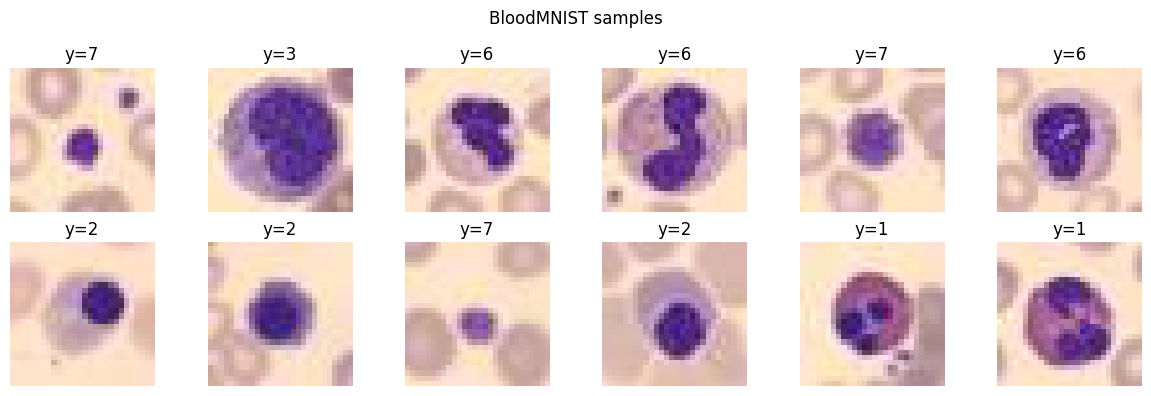

In [3]:
# ============================================================
# S2. DATASET LOADING + VALIDATION
# ============================================================

def load_medmnist_split(dataset_name: str, split: str, download: bool = True):
    if dataset_name not in INFO:
        raise ValueError(f"Unknown MedMNIST dataset: {dataset_name}")
    info = INFO[dataset_name]
    DataClass = getattr(medmnist, info["python_class"])
    ds = DataClass(split=split, download=download)

    imgs = np.asarray(ds.imgs)
    labels = np.asarray(ds.labels).reshape(-1).astype(np.int64)

    if imgs.ndim == 3:
        imgs = imgs[..., None]
    if imgs.shape[-1] == 1:
        imgs = np.repeat(imgs, 3, axis=-1)
    if imgs.shape[-1] != 3:
        raise ValueError(f"Expected RGB/grayscale data, got {imgs.shape}")

    X = torch.tensor(imgs, dtype=torch.float32).permute(0, 3, 1, 2) / 255.0
    y = torch.tensor(labels, dtype=torch.long)
    return X, y, info

def label_map_to_int(label_map):
    out = {}
    for k, v in label_map.items():
        try:
            out[int(k)] = str(v)
        except Exception:
            pass
    return dict(sorted(out.items()))

def resolve_class_id(label_map, hint, fallback, role):
    matches = [i for i, name in label_map.items() if hint.lower() in name.lower()]
    if len(matches) == 1:
        resolved = int(matches[0])
        if resolved != fallback:
            print(f"[class-id correction] {role}: configured {fallback}, metadata resolves '{hint}' -> {resolved}")
        return resolved
    msg = f"needs verification: could not uniquely resolve {role}='{hint}'. Using fallback id={fallback}."
    print("[warning]", msg)
    NEEDS_VERIFICATION.append(msg)
    return int(fallback)

X_train_raw, y_train_raw, dataset_info = load_medmnist_split(cfg.dataset_name, "train", download=True)
X_val_official, y_val_official, _ = load_medmnist_split(cfg.dataset_name, "val", download=True)
X_test_raw, y_test_raw, _ = load_medmnist_split(cfg.dataset_name, "test", download=True)

label_map = label_map_to_int(dataset_info.get("label", {}))
display(pd.DataFrame({"class_id": list(label_map.keys()), "class_name": list(label_map.values())}))

if len(label_map) != cfg.n_classes:
    msg = f"needs verification: expected {cfg.n_classes} classes, found {len(label_map)} in metadata."
    print("[warning]", msg)
    NEEDS_VERIFICATION.append(msg)

if cfg.auto_resolve_class_ids:
    cfg.source_class = resolve_class_id(label_map, cfg.source_name_hint, cfg.source_class, "source")
    cfg.target_class = resolve_class_id(label_map, cfg.target_name_hint, cfg.target_class, "target")

if cfg.source_class == cfg.target_class:
    raise ValueError("Source and target classes are identical. Fix cfg.source_class/cfg.target_class.")

print(f"Final source class: {cfg.source_class} | {label_map.get(cfg.source_class, 'unknown')}")
print(f"Final target class: {cfg.target_class} | {label_map.get(cfg.target_class, 'unknown')}")
print("Shapes:", X_train_raw.shape, X_val_official.shape, X_test_raw.shape)

def class_count_table(y, split):
    counts = pd.Series(y.cpu().numpy()).value_counts().sort_index()
    return pd.DataFrame({"split": split, "class_id": counts.index, "count": counts.values})

dist_df = pd.concat([
    class_count_table(y_train_raw, "train"),
    class_count_table(y_val_official, "val"),
    class_count_table(y_test_raw, "test"),
], ignore_index=True)
display(dist_df.pivot_table(index="class_id", columns="split", values="count", fill_value=0).astype(int))

def show_image_grid(X, y, n=12, title="Sample images"):
    n = min(n, len(X))
    cols = min(n, 6)
    rows = math.ceil(n / cols)
    plt.figure(figsize=(cols * 2, rows * 2))
    for i in range(n):
        plt.subplot(rows, cols, i+1)
        plt.imshow(X[i].permute(1, 2, 0).cpu().numpy())
        plt.title(f"y={int(y[i])}")
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_image_grid(X_train_raw, y_train_raw, n=12, title="BloodMNIST samples")


In [4]:

# ============================================================
# Scope and leakage assertions
# ============================================================
assert cfg.dataset_name.lower() == "bloodmnist", "Notebook 1 must use BloodMNIST only."
assert cfg.attack_type == "qtrojan", "Notebook 1 must run QTrojan only."
assert cfg.source_class is not None
assert cfg.target_class is not None
assert len(cfg.seeds) == 3, "Configured seed list must remain the 3-seed protocol."
assert cfg.n_qubits == 8
assert cfg.vqc_layers == 4
assert cfg.obs_mode == "ZX_ALT"
print("Scope assertions passed: BloodMNIST / QTrojan / 3 seeds / 8-qubit VQC.")


Scope assertions passed: BloodMNIST / QTrojan / 3 seeds / 8-qubit VQC.


In [5]:
# ============================================================
# S3-S7. MODEL + TRAINING HELPERS
# ============================================================

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1)

def preprocess_for_resnet(x, model_image_size):
    x = F.interpolate(x, size=(model_image_size, model_image_size), mode="bilinear", align_corners=False)
    return (x - IMAGENET_MEAN.to(x.device)) / IMAGENET_STD.to(x.device)

def measurement_dim(n_qubits, obs_mode):
    obs = obs_mode.upper().strip()
    if obs in ["Z_ONLY", "ZX_ALT"]:
        return n_qubits
    if obs == "XYZ":
        return 3 * n_qubits
    raise ValueError(f"Unknown obs_mode={obs_mode}")

def make_vqc_qnode(n_qubits, n_layers, obs_mode="ZX_ALT"):
    try:
        dev = qml.device("lightning.qubit", wires=n_qubits)
    except Exception:
        print("[warning] lightning.qubit unavailable; using default.qubit")
        dev = qml.device("default.qubit", wires=n_qubits)
    obs = obs_mode.upper().strip()

    @qml.qnode(dev, interface="torch", diff_method="best")
    def circuit(angles, weights, input_scales, input_bias, trojan_angles, trigger_flag):
        for layer in range(n_layers):
            for q in range(n_qubits):
                qml.Rot(weights[layer, q, 0], weights[layer, q, 1], weights[layer, q, 2], wires=q)
            for q in range(n_qubits):
                qml.RY(input_scales[layer, q] * angles[q] + input_bias[layer, q], wires=q)

            # Critical isolation: trigger_flag=0 disables the inserted QTrojan RY gate.
            for q in range(n_qubits):
                qml.RY(trigger_flag * trojan_angles[layer, q], wires=q)

            if layer % 2 == 0:
                for q in range(n_qubits):
                    qml.CNOT(wires=[q, (q + 1) % n_qubits])
            else:
                for q in range(n_qubits):
                    qml.CNOT(wires=[(q + 1) % n_qubits, q])

        if obs == "Z_ONLY":
            return [qml.expval(qml.PauliZ(q)) for q in range(n_qubits)]
        if obs == "XYZ":
            out = []
            for q in range(n_qubits):
                out.extend([qml.expval(qml.PauliX(q)), qml.expval(qml.PauliY(q)), qml.expval(qml.PauliZ(q))])
            return out
        return [qml.expval(qml.PauliZ(q)) if q % 2 == 0 else qml.expval(qml.PauliX(q)) for q in range(n_qubits)]
    return circuit

class StrongVQCMeasurementLayer(nn.Module):
    def __init__(self, in_dim, n_qubits, n_layers, obs_mode, trojan_init_std):
        super().__init__()
        self.n_qubits = n_qubits
        self.n_layers = n_layers
        self.obs_mode = obs_mode
        self.compress = nn.Sequential(
            nn.LayerNorm(in_dim),
            nn.Linear(in_dim, 32),
            nn.Tanh(),
            nn.Linear(32, n_qubits),
            nn.Tanh(),
        )
        self.weights = nn.Parameter(0.01 * torch.randn(n_layers, n_qubits, 3))
        self.input_scales = nn.Parameter(torch.ones(n_layers, n_qubits))
        self.input_bias = nn.Parameter(torch.zeros(n_layers, n_qubits))
        self.trojan_angles = nn.Parameter(trojan_init_std * torch.randn(n_layers, n_qubits))
        self.qnode = make_vqc_qnode(n_qubits, n_layers, obs_mode)

    def forward(self, context, trojan_mask=None):
        angles = math.pi * (self.compress(context) + 1.0) / 2.0
        if trojan_mask is None:
            trojan_mask = torch.zeros(angles.shape[0], device=angles.device, dtype=angles.dtype)
        else:
            trojan_mask = trojan_mask.to(device=angles.device, dtype=angles.dtype).view(-1)

        vals = [
            torch.stack(self.qnode(a, self.weights, self.input_scales, self.input_bias, self.trojan_angles, flag)).float()
            for a, flag in zip(angles, trojan_mask)
        ]
        return torch.stack(vals, dim=0)

class QMedShieldHybridQNN(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        weights = None
        if cfg.use_imagenet_weights:
            try:
                weights = ResNet18_Weights.IMAGENET1K_V1
            except Exception:
                weights = None
        try:
            resnet = models.resnet18(weights=weights)
        except Exception as exc:
            msg = f"needs verification: ImageNet weights unavailable ({exc}); using random ResNet-18 init."
            print("[warning]", msg)
            NEEDS_VERIFICATION.append(msg)
            resnet = models.resnet18(weights=None)

        self.stem = nn.Sequential(*list(resnet.children())[:-2])
        if cfg.freeze_resnet_lower_blocks:
            for p in self.stem[:6].parameters():
                p.requires_grad = False

        self.rnn = nn.GRU(input_size=512, hidden_size=256, num_layers=2,
                          batch_first=True, bidirectional=True, dropout=0.2)
        self.vqc = StrongVQCMeasurementLayer(512, cfg.n_qubits, cfg.vqc_layers, cfg.obs_mode, cfg.trojan_init_std)
        self.q_head = nn.Linear(measurement_dim(cfg.n_qubits, cfg.obs_mode), cfg.n_classes)

    def _context(self, x_preprocessed):
        feats = self.stem(x_preprocessed)
        B, C, H, W = feats.shape
        seq = feats.view(B, C, H*W).permute(0, 2, 1)
        out, _ = self.rnn(seq)
        return out.mean(dim=1)

    def _mask(self, batch_size, device, t=0.0, trojan_mask=None):
        if trojan_mask is not None:
            return trojan_mask.to(device=device, dtype=torch.float32).view(-1)
        if isinstance(t, torch.Tensor):
            return t.to(device=device, dtype=torch.float32).view(-1)
        return torch.full((batch_size,), float(t), device=device, dtype=torch.float32)

    def forward(self, x_preprocessed, t=0.0, return_measurements=False, trojan_mask=None):
        ctx = self._context(x_preprocessed)
        mask = self._mask(ctx.shape[0], ctx.device, t=t, trojan_mask=trojan_mask)
        qfeat = self.vqc(ctx, trojan_mask=mask)
        logits = self.q_head(qfeat)
        if return_measurements:
            return logits, qfeat, ctx
        return logits

    @torch.no_grad()
    def extract_vqc_measurements(self, x_raw, t=0.0):
        xp = preprocess_for_resnet(x_raw, self.cfg.model_image_size)
        _, qfeat, _ = self.forward(xp, t=t, return_measurements=True)
        return qfeat

def verify_architecture(model, cfg, device):
    model = model.to(device)
    dummy = torch.rand(4, 3, cfg.native_image_size, cfg.native_image_size, device=device)
    xp = preprocess_for_resnet(dummy, cfg.model_image_size)
    logits, qfeat, ctx = model(xp, t=0, return_measurements=True)
    assert logits.shape == (4, cfg.n_classes), logits.shape
    assert qfeat.shape == (4, measurement_dim(cfg.n_qubits, cfg.obs_mode)), qfeat.shape
    assert ctx.shape == (4, 512), ctx.shape
    print("Architecture verified:", logits.shape, qfeat.shape, ctx.shape)

def stratified_limit_tensors(X, y, max_n, seed):
    if max_n is None or len(y) <= max_n:
        return X, y, np.arange(len(y))
    idx = np.arange(len(y))
    _, keep = train_test_split(idx, test_size=max_n, random_state=seed, stratify=y.cpu().numpy())
    keep = np.sort(keep)
    return X[keep], y[keep], keep

def make_train_val_split(X, y, cfg, seed):
    X_lim, y_lim, keep = stratified_limit_tensors(X, y, cfg.max_train_n, seed)
    idx = np.arange(len(y_lim))
    tr, va = train_test_split(idx, test_size=cfg.val_size, random_state=seed, stratify=y_lim.cpu().numpy())
    tr, va = np.sort(tr), np.sort(va)
    return {"X_train": X_lim[tr], "y_train": y_lim[tr], "X_val": X_lim[va], "y_val": y_lim[va], "source_idx": keep}

def augment_train_only(X, seed):
    set_all_seeds(seed)
    aug = T.Compose([T.RandomHorizontalFlip(p=0.5), T.RandomCrop(X.shape[-1], padding=2, padding_mode="reflect")])
    return torch.stack([aug(img) for img in X])

def make_loader(X, y, batch_size, shuffle):
    return DataLoader(TensorDataset(X.float(), y.long()), batch_size=batch_size, shuffle=shuffle, num_workers=0)

def set_trainable(module, trainable):
    for p in module.parameters():
        p.requires_grad = trainable

def optimizer_for_stage(model, cfg, stage):
    if stage == "trojan":
        params = []
        params.append({"params": [model.vqc.trojan_angles], "lr": cfg.lr_base * cfg.lr_trojan_mult})
        other_vqc = [p for n, p in model.vqc.named_parameters() if n != "trojan_angles" and p.requires_grad]
        if other_vqc:
            params.append({"params": other_vqc, "lr": cfg.lr_base})
        params.append({"params": model.q_head.parameters(), "lr": cfg.lr_base})
        return torch.optim.AdamW(params, weight_decay=cfg.weight_decay)

    return torch.optim.AdamW([
        {"params": model.stem[6:].parameters(), "lr": cfg.lr_base * 0.1},
        {"params": model.rnn.parameters(), "lr": cfg.lr_base},
        {"params": model.vqc.parameters(), "lr": cfg.lr_base},
        {"params": model.q_head.parameters(), "lr": cfg.lr_base},
    ], weight_decay=cfg.weight_decay)

@torch.no_grad()
def evaluate_classifier(model, X, y, cfg, device, trojan_t=0.0):
    model.eval()
    loader = make_loader(X, y, cfg.eval_batch_size, shuffle=False)
    preds, probs = [], []
    for xb, _ in loader:
        xb = preprocess_for_resnet(xb.to(device), cfg.model_image_size)
        logits = model(xb, t=trojan_t)
        prob = torch.softmax(logits, dim=1).cpu().numpy()
        preds.append(prob.argmax(axis=1))
        probs.append(prob)
    preds = np.concatenate(preds)
    probs = np.concatenate(probs)
    y_np = y.cpu().numpy() if isinstance(y, torch.Tensor) else np.asarray(y)
    return {
        "accuracy": float(accuracy_score(y_np, preds)),
        "macro_f1": float(f1_score(y_np, preds, average="macro", zero_division=0)),
        "preds": preds,
        "probs": probs,
    }

@torch.no_grad()
def evaluate_qtrojan_asr(model, X, y, cfg, device, seed):
    y_np = y.cpu().numpy() if isinstance(y, torch.Tensor) else np.asarray(y)
    idx = np.where(y_np == cfg.source_class)[0]
    if len(idx) == 0:
        raise ValueError("No source-class samples for ASR.")
    rng = np.random.default_rng(seed)
    if cfg.max_asr_n and len(idx) > cfg.max_asr_n:
        idx = rng.choice(idx, size=cfg.max_asr_n, replace=False)
    idx = np.sort(idx)
    y_target = torch.full((len(idx),), cfg.target_class, dtype=torch.long)
    out = evaluate_classifier(model, X[idx], y_target, cfg, device, trojan_t=1.0)
    out["n_source_eval"] = int(len(idx))
    return out

def train_clean_stage(model, train_loader, val_loader, cfg, device):
    model = model.to(device)
    opt = optimizer_for_stage(model, cfg, "clean")
    hist = []
    print(f"Stage A clean training: {cfg.clean_epochs} epochs")
    for ep in range(1, cfg.clean_epochs + 1):
        model.train()
        loss_sum, n = 0.0, 0
        for xb, yb in train_loader:
            xb = preprocess_for_resnet(xb.to(device), cfg.model_image_size)
            yb = yb.to(device)
            opt.zero_grad()
            logits = model(xb, t=0.0)
            loss = F.cross_entropy(logits, yb, label_smoothing=cfg.label_smoothing)
            loss.backward()
            opt.step()
            loss_sum += float(loss.detach().cpu()) * len(xb)
            n += len(xb)
        val = evaluate_classifier(model, val_loader.dataset.tensors[0], val_loader.dataset.tensors[1], cfg, device, 0.0)
        row = {"epoch": ep, "stage": "clean", "loss": loss_sum/max(n,1), "val_acc": val["accuracy"], "val_macro_f1": val["macro_f1"]}
        hist.append(row)
        print(f"Epoch {ep:02d}: loss={row['loss']:.4f}, val_CA={row['val_acc']:.4f}")
    return model, hist

def train_qtrojan_stage(model, train_loader, val_loader, cfg, device):
    """
    QTrojan optimization stage.

    The previous short run underfit the attack (ASR below the configured gate).
    This version keeps the classical encoder frozen by default, but adds a small
    source-only trigger boost so every epoch sees enough source->target attack
    signal without making the notebook too heavy for Kaggle T4.
    """
    model = model.to(device)
    if cfg.freeze_classical_in_trojan_stage:
        set_trainable(model.stem, False)
        set_trainable(model.rnn, False)
        print("Frozen ResNet/BiGRU during QTrojan stage.")
    set_trainable(model.vqc, True)
    set_trainable(model.q_head, True)

    # Source-only loader for stable trigger optimization.
    X_all, y_all = train_loader.dataset.tensors
    src_mask = (y_all == cfg.source_class)
    if int(src_mask.sum()) == 0:
        raise ValueError("No source-class samples in training split; cannot train QTrojan.")
    src_dataset = TensorDataset(X_all[src_mask], y_all[src_mask])
    src_loader = DataLoader(
        src_dataset,
        batch_size=min(cfg.train_batch_size, len(src_dataset)),
        shuffle=True,
        drop_last=False
    )

    opt = optimizer_for_stage(model, cfg, "trojan")
    hist = []
    print(f"Stage B QTrojan training: {cfg.qtrojan_epochs} epochs")
    for ep in range(1, cfg.qtrojan_epochs + 1):
        model.train()
        loss_sum, n, tbatches = 0.0, 0, 0

        # Mixed clean + in-batch source attack pass.
        for xb, yb in train_loader:
            xb = preprocess_for_resnet(xb.to(device), cfg.model_image_size)
            yb = yb.to(device)
            opt.zero_grad()

            logits_clean = model(xb, t=0.0)
            loss_clean = F.cross_entropy(logits_clean, yb, label_smoothing=cfg.label_smoothing)

            src_idx = torch.where(yb == cfg.source_class)[0]
            if len(src_idx) > 0:
                target = torch.full((len(src_idx),), cfg.target_class, dtype=torch.long, device=device)
                logits_trig = model(xb[src_idx], t=1.0)
                loss_trig = F.cross_entropy(logits_trig, target)
                loss = cfg.clean_loss_weight_trojan * loss_clean + cfg.q_loss_weight_trojan * loss_trig
                tbatches += 1
            else:
                loss = cfg.clean_loss_weight_trojan * loss_clean

            loss.backward()
            opt.step()
            loss_sum += float(loss.detach().cpu()) * len(xb)
            n += len(xb)

        # Lightweight source-only trigger boost. This usually improves ASR
        # without unfreezing the full ResNet/BiGRU stack.
        if cfg.qtrojan_source_boost_batches > 0:
            for b_i, (xs, _) in enumerate(src_loader):
                if b_i >= cfg.qtrojan_source_boost_batches:
                    break
                xs = preprocess_for_resnet(xs.to(device), cfg.model_image_size)
                target = torch.full((len(xs),), cfg.target_class, dtype=torch.long, device=device)
                opt.zero_grad()
                logits_trig = model(xs, t=1.0)
                loss_boost = cfg.q_loss_weight_trojan * F.cross_entropy(logits_trig, target)
                loss_boost.backward()
                opt.step()
                loss_sum += float(loss_boost.detach().cpu()) * len(xs)
                n += len(xs)
                tbatches += 1

        val_ca = evaluate_classifier(model, val_loader.dataset.tensors[0], val_loader.dataset.tensors[1], cfg, device, 0.0)
        val_asr = evaluate_qtrojan_asr(model, val_loader.dataset.tensors[0], val_loader.dataset.tensors[1], cfg, device, cfg.primary_seed)
        row = {"epoch": ep, "stage": "qtrojan", "loss": loss_sum/max(n,1), "val_ca": val_ca["accuracy"], "val_asr": val_asr["accuracy"], "trojan_batches": tbatches}
        hist.append(row)
        print(f"Epoch {ep:02d}: loss={row['loss']:.4f}, val_CA={row['val_ca']:.4f}, val_ASR={row['val_asr']:.4f}")
        if val_ca["accuracy"] >= cfg.clean_acc_min and val_asr["accuracy"] >= cfg.asr_min:
            print("Early stop: CA/ASR gates reached.")
            break
    return model, hist


In [6]:
# ============================================================
# S8-S13. QTROJAN PIPELINE + CC-QMC DETECTION
# ============================================================

@torch.no_grad()
def extract_measurements_and_context(model, X, cfg, device, trojan_mask_np=None, t_forced=None):
    model.eval()
    if t_forced is not None:
        masks = torch.full((len(X),), float(t_forced), dtype=torch.float32)
    elif trojan_mask_np is not None:
        masks = torch.tensor(trojan_mask_np, dtype=torch.float32)
    else:
        masks = torch.zeros(len(X), dtype=torch.float32)
    qs, ctxs, preds = [], [], []
    for s in range(0, len(X), cfg.eval_batch_size):
        e = min(s + cfg.eval_batch_size, len(X))
        xb = preprocess_for_resnet(X[s:e].to(device), cfg.model_image_size)
        tb = masks[s:e].to(device)
        logits, qfeat, ctx = model(xb, trojan_mask=tb, return_measurements=True)
        qs.append(qfeat.cpu())
        ctxs.append(ctx.cpu())
        preds.append(logits.argmax(dim=1).cpu())
    return torch.cat(qs).numpy(), torch.cat(ctxs).numpy(), torch.cat(preds).numpy()

@torch.no_grad()
def extract_delta_measurements(model, X, cfg, device):
    model.eval()
    feats, ctxs = [], []
    for s in range(0, len(X), cfg.eval_batch_size):
        e = min(s + cfg.eval_batch_size, len(X))
        xb = preprocess_for_resnet(X[s:e].to(device), cfg.model_image_size)
        b = xb.shape[0]
        zeros = torch.zeros(b, device=device)
        ones = torch.ones(b, device=device)
        _, q0, ctx = model(xb, trojan_mask=zeros, return_measurements=True)
        _, q1, _ = model(xb, trojan_mask=ones, return_measurements=True)
        feats.append(torch.cat([q0, q1, torch.abs(q1-q0)], dim=1).cpu())
        ctxs.append(ctx.cpu())
    return torch.cat(feats).numpy(), torch.cat(ctxs).numpy()



In [7]:

# ============================================================
# Aggregation + matched classical comparison + Q1-level superiority audit
# QTrojan / BloodMNIST — Notebook 2
# ============================================================

from pathlib import Path
import shutil
from datetime import datetime

# Robust local imports for Notebook-2 classical baselines.
# These are intentionally repeated here so the aggregation cell works even
# when Colab is restarted and only the restore/config cells were run.
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score

cfg.aggregate_only = True
cfg.run_qsentry_rate_sweep = False
cfg.run_full_reset_upper_bound = False
STRICT_REQUIRE_ALL_SEEDS = False  # partial preview allowed; final Q1 claim still requires all seeds
OUT_DIR = Path(cfg.out_dir)
OUT_DIR.mkdir(parents=True, exist_ok=True)

REPAIR_FILE_MAP = {
    "no_repair": "repair_no_repair.csv",
    "random_samek": "repair_random_samek.csv",
    "magnitude_samek": "repair_magnitude_samek.csv",
    "gradient_samek": "repair_gradient_samek.csv",
    "qxai_samek": "repair_qxai_samek.csv",
}

LITERATURE_AUDIT_ROWS = [
    {
        "Paper / Method": "QSentry: Measurement Clustering for QNN backdoor detection",
        "Relevant Evaluation Rule": "Evaluate QNN backdoor detection from measurement-output anomalies; report low-poison-rate performance and clustering evidence.",
        "What My Notebook Currently Does": "Aggregates CC-QMC/QSentry-style detection summaries when seed-level pipeline_detection_summary.csv files exist; optional rate sweep is disabled by default to protect Colab runtime.",
        "Gap": "Low-rate 1/5/10/15% sweep is not rerun by default; if enabled, it must use validation-selected K/thresholds and final test reporting only.",
        "Fix Applied": "Notebook 2 separates core attack/repair aggregation from optional QSentry sweep and records detection comparison only from computed seed files.",
        "Source Checked": "https://arxiv.org/abs/2511.15376",
    },
    {
        "Paper / Method": "QTrojan: circuit-level backdoor against QNNs",
        "Relevant Evaluation Rule": "Treat QTrojan as circuit-level behavior: clean behavior under normal mode, target misclassification under trigger activation, and circuit/parameter-level repair.",
        "What My Notebook Currently Does": "Uses QTrojan/BloodMNIST source-target setting; evaluates clean CA and ASR before repair; QXAI repair acts on trojan_angles only.",
        "Gap": "Dormant forced-t0 detection remains a limitation unless computed metrics prove otherwise.",
        "Fix Applied": "Claim report explicitly separates activated circuit-level repair from dormant detection claims.",
        "Source Checked": "https://arxiv.org/abs/2302.08090",
    },
    {
        "Paper / Method": "Backdoor defense evaluation practice",
        "Relevant Evaluation Rule": "Report clean accuracy and ASR before/after defense; compare repair methods against baselines and preserve clean accuracy.",
        "What My Notebook Currently Does": "Aggregates no-repair, random same-k, magnitude same-k, gradient/finite-difference same-k, and QXAI same-k repair CSVs.",
        "Gap": "QXAI superiority cannot be claimed from localization alone.",
        "Fix Applied": "QXAI claim is computed from ASR reduction versus all same-k baselines, with clean-CA preservation tracked.",
        "Source Checked": "https://arxiv.org/abs/1805.12185 and https://proceedings.neurips.cc/paper/2021/file/7d38b1e9bd793d3f45e0e212a729a93c-Paper.pdf",
    },
    {
        "Paper / Method": "Detection metrics under imbalance",
        "Relevant Evaluation Rule": "Use threshold-dependent metrics such as F1/precision/recall and threshold-independent AUROC/AUPRC; avoid selecting thresholds on test labels.",
        "What My Notebook Currently Does": "Reads computed F1/precision/recall/AUPRC/AUROC where available and does not recalibrate thresholds on test outputs in Notebook 2.",
        "Gap": "If AUROC or AUPRC is missing from upstream CSVs, the report labels that metric as needs verification instead of inventing it.",
        "Fix Applied": "Superiority table uses only columns present in saved runtime files; missing metrics are not fabricated.",
        "Source Checked": "https://arxiv.org/html/2405.09786v1 and https://arxiv.org/abs/2401.06091",
    },
]


def seed_dir(seed, cfg):
    return os.path.join(cfg.out_dir, f"seed_{int(seed)}")


def seed_file(seed, filename, cfg):
    return os.path.join(seed_dir(seed, cfg), filename)


def _safe_torch_load(path, map_location="cpu"):
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)


def _read_csv_required(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing required file: {path}")
    return pd.read_csv(path)


def required_seed_files(seed, cfg):
    files = [
        seed_file(seed, "attack_success.csv", cfg),
        seed_file(seed, "repair_no_repair.csv", cfg),
        seed_file(seed, "repair_random_samek.csv", cfg),
        seed_file(seed, "repair_magnitude_samek.csv", cfg),
        seed_file(seed, "repair_gradient_samek.csv", cfg),
        seed_file(seed, "repair_qxai_samek.csv", cfg),
        seed_file(seed, "seed_status.json", cfg),
    ]
    return files


def find_missing_seed_files(cfg):
    missing = []
    for seed in cfg.seeds:
        for path in required_seed_files(seed, cfg):
            if not os.path.exists(path):
                missing.append({"Seed": int(seed), "Missing File": path})
    return pd.DataFrame(missing)


def _seed_has_required_outputs(seed, cfg):
    return all(os.path.exists(path) for path in required_seed_files(seed, cfg))


def available_complete_seeds(cfg):
    available = []
    rows = []
    for seed in cfg.seeds:
        seed_path = os.path.join(cfg.out_dir, f"seed_{int(seed)}")
        required_ok = _seed_has_required_outputs(seed, cfg)
        status_path = seed_file(seed, "seed_status.json", cfg)
        status_complete = False
        if os.path.exists(status_path):
            try:
                with open(status_path, "r", encoding="utf-8") as f:
                    status_complete = bool(json.load(f).get("complete", False))
            except Exception:
                status_complete = False
        is_available = bool(required_ok and status_complete)
        if is_available:
            available.append(int(seed))
        rows.append({
            "Seed": int(seed),
            "Seed Folder Exists": os.path.isdir(seed_path),
            "Files Found": len([p for p in glob.glob(os.path.join(seed_path, "*"))]) if os.path.isdir(seed_path) else 0,
            "Required Files Present": required_ok,
            "Status Complete Flag": status_complete,
            "Available For Aggregation": is_available,
            "Expected Folder": seed_path,
        })
    return available, pd.DataFrame(rows)


def enforce_seed_outputs_available(cfg):
    missing_df = find_missing_seed_files(cfg)
    available, present_df = available_complete_seeds(cfg)
    print("Per-seed folder inspection:")
    display(present_df)
    cfg.active_aggregation_seeds = tuple(available)
    cfg.missing_aggregation_seeds = tuple(int(s) for s in cfg.seeds if int(s) not in available)

    # Always save missing manifest for debugging, without inventing metrics.
    missing_path = os.path.join(cfg.out_dir, "aggregation_missing_seed_outputs.csv")
    if not missing_df.empty:
        missing_df.to_csv(missing_path, index=False)
        print("Missing required per-seed files from Notebook 1:")
        display(missing_df)
        print(f"Missing-file manifest saved: {missing_path}")

    if not available:
        raise FileNotFoundError(
            "No complete seed outputs are available. Put Notebook-1 seed zips at a fixed path such as "
            "/content/outputs_qtrojan_bloodmnist_seed_42.zip, rerun Cell 1, then rerun this cell."
        )

    if missing_df.empty:
        print("All required per-seed files are present. Final 3-seed aggregation enabled.")
        cfg.partial_aggregation_preview = False
        return tuple(available)

    if bool(getattr(cfg, "allow_partial_aggregation_preview", True)) and not bool(STRICT_REQUIRE_ALL_SEEDS):
        print("[PARTIAL PREVIEW] Aggregating available seeds only:", tuple(available))
        print("[NOT FINAL] Missing seeds:", cfg.missing_aggregation_seeds)
        print("Final Q1-level claim remains blocked until all seeds are complete.")
        cfg.partial_aggregation_preview = True
        return tuple(available)

    missing_seeds = sorted(missing_df["Seed"].unique().tolist())
    raise FileNotFoundError(
        "Notebook 2 cannot make a final 3-seed claim yet. Missing seed outputs for: "
        f"{missing_seeds}. Run Notebook 1 AutoNext for each missing seed and ensure fixed-path zips exist, e.g. "
        "/content/outputs_qtrojan_bloodmnist_seed_123.zip and /content/outputs_qtrojan_bloodmnist_seed_777.zip."
    )


def _aggregation_seed_list(cfg):
    return tuple(getattr(cfg, "active_aggregation_seeds", cfg.seeds))


def read_completed_seed_outputs(cfg):
    attack_frames, repair_frames, status_rows, detection_frames = [], [], [], []
    for seed in _aggregation_seed_list(cfg):
        with open(seed_file(seed, "seed_status.json", cfg), "r", encoding="utf-8") as f:
            status = json.load(f)
        status_rows.append(status)
        if not bool(status.get("complete", False)):
            raise RuntimeError(f"seed_{seed} is not COMPLETE. Finish Notebook 1 for that seed first.")
        attack_df = pd.read_csv(seed_file(seed, "attack_success.csv", cfg))
        attack_df["Seed"] = int(seed)
        attack_frames.append(attack_df)
        for method, filename in REPAIR_FILE_MAP.items():
            path = seed_file(seed, filename, cfg)
            df = pd.read_csv(path)
            df["Seed"] = int(seed)
            df["method"] = method
            df["Source File"] = path
            repair_frames.append(df)
        det_path = seed_file(seed, "pipeline_detection_summary.csv", cfg)
        if os.path.exists(det_path):
            det_df = pd.read_csv(det_path)
            det_df["Seed"] = int(seed)
            det_df["Source File"] = det_path
            detection_frames.append(det_df)
    attack_df = collapse_duplicate_columns(pd.concat(attack_frames, ignore_index=True))
    repair_df = collapse_duplicate_columns(pd.concat(repair_frames, ignore_index=True))
    status_df = collapse_duplicate_columns(pd.DataFrame(status_rows))
    detection_df = collapse_duplicate_columns(pd.concat(detection_frames, ignore_index=True)) if detection_frames else pd.DataFrame()
    return attack_df, repair_df, status_df, detection_df


def collapse_duplicate_columns(df):
    """Coalesce duplicate column names caused by mixed-version CSVs.

    Pandas returns a DataFrame, not a Series, when df["col"] has duplicate
    column labels. That breaks .str accessors. This helper keeps the first
    non-null value across duplicate columns and preserves the original evidence.
    """
    if not isinstance(df, pd.DataFrame):
        return df
    if not df.columns.duplicated().any():
        return df
    out = pd.DataFrame(index=df.index)
    for col in pd.Index(df.columns).unique():
        block = df.loc[:, df.columns == col]
        if isinstance(block, pd.DataFrame):
            if block.shape[1] == 1:
                out[col] = block.iloc[:, 0]
            else:
                out[col] = block.bfill(axis=1).iloc[:, 0]
        else:
            out[col] = block
    return out


def col_series(df, col, default=None):
    """Return a Series even if a CSV created duplicate column names."""
    if col not in df.columns:
        if default is None:
            raise KeyError(f"Missing required column: {col}")
        return pd.Series([default] * len(df), index=df.index)
    value = df.loc[:, col]
    if isinstance(value, pd.DataFrame):
        if value.shape[1] == 1:
            return value.iloc[:, 0]
        return value.bfill(axis=1).iloc[:, 0]
    return value


def normalize_repair_columns(df):
    """Make column names robust across notebook versions without inventing values."""
    rename_map = {}
    for col in df.columns:
        low = str(col).lower().strip()
        if low in ["repair method", "method", "repair_method"]:
            rename_map[col] = "method"
        elif low in ["ca after", "ca_after", "clean_acc_after", "clean_accuracy_after", "repair ca after repair", "repair_ca", "ca"]:
            rename_map[col] = "ca_after_repair"
        elif low in ["asr after", "asr_after", "repair asr after repair", "repair_asr", "asr"]:
            rename_map[col] = "asr_after_repair"
        elif low in ["qtrojan asr before repair", "asr_before", "pre_asr", "asr_before_repair"]:
            rename_map[col] = "asr_before_repair"
        elif low in ["params reset", "changed params", "params_reset", "n_params_reset", "num_params_reset", "k"]:
            rename_map[col] = "params_reset"
        elif low in ["runtime sec", "runtime", "runtime_sec", "time_sec"]:
            rename_map[col] = "runtime_sec"
        elif low in ["same-k?", "same-k comparison", "same_k"]:
            rename_map[col] = "same_k"
    df = collapse_duplicate_columns(df.rename(columns=rename_map))
    if "method" in df.columns:
        method_s = col_series(df, "method").astype(str)
        method_s = method_s.str.replace("random_same_k_reset", "random_samek", regex=False)
        method_s = method_s.str.replace("magnitude_same_k_reset", "magnitude_samek", regex=False)
        method_s = method_s.str.replace("gradient_same_k_reset", "gradient_samek", regex=False)
        method_s = method_s.str.replace("qxai_same_k_reset", "qxai_samek", regex=False)
        df["method"] = method_s
    if "same_k" not in df.columns and "method" in df.columns:
        df["same_k"] = col_series(df, "method").isin(["random_samek", "magnitude_samek", "gradient_samek", "qxai_samek"])
    if "asr_before_repair" not in df.columns and {"seed", "asr_after_repair", "method"}.issubset(df.columns):
        before_by_seed = df[col_series(df, "method").eq("no_repair")].groupby("seed")["asr_after_repair"].mean().to_dict()
        df["asr_before_repair"] = col_series(df, "seed").map(before_by_seed)
    if "asr_reduction" not in df.columns and {"asr_before_repair", "asr_after_repair"}.issubset(df.columns):
        df["asr_reduction"] = df["asr_before_repair"] - df["asr_after_repair"]
    return df


def summarize_attack_and_repair(attack_df, repair_df, cfg):
    out_dir = cfg.out_dir
    os.makedirs(out_dir, exist_ok=True)
    attack_path = os.path.join(out_dir, "qtrojan_final_attack_success_3seed.csv")
    raw_repair_path = os.path.join(out_dir, "qtrojan_repair_all_seed_rows.csv")
    repair_path = os.path.join(out_dir, "qtrojan_final_repair_baseline_comparison_3seed.csv")
    summary_path = os.path.join(out_dir, "qtrojan_final_summary_mean_std.csv")
    attack_df.to_csv(attack_path, index=False)
    repair_norm = normalize_repair_columns(repair_df.copy())
    repair_norm.to_csv(raw_repair_path, index=False)
    required_cols = {"Seed", "method", "ca_after_repair", "asr_after_repair", "asr_reduction"}
    missing_cols = sorted(required_cols - set(repair_norm.columns))
    if missing_cols:
        raise ValueError(f"Repair CSVs are missing required columns: {missing_cols}")
    summary = (
        repair_norm
        .groupby("method")
        .agg(
            ca_after_mean=("ca_after_repair", "mean"),
            ca_after_std=("ca_after_repair", "std"),
            asr_after_mean=("asr_after_repair", "mean"),
            asr_after_std=("asr_after_repair", "std"),
            asr_reduction_mean=("asr_reduction", "mean"),
            asr_reduction_std=("asr_reduction", "std"),
            params_reset_mean=("params_reset", "mean") if "params_reset" in repair_norm.columns else ("asr_reduction", "count"),
            runtime_sec_mean=("runtime_sec", "mean") if "runtime_sec" in repair_norm.columns else ("asr_reduction", "count"),
        )
        .reset_index()
        .sort_values("asr_reduction_mean", ascending=False)
    )
    repair_norm.to_csv(raw_repair_path, index=False)
    summary.to_csv(repair_path, index=False)
    summary.to_csv(summary_path, index=False)
    return attack_path, raw_repair_path, repair_path, summary_path, summary, repair_norm


def aggregate_qxai_repair_superiority(repair_norm, cfg):
    summary = pd.read_csv(os.path.join(cfg.out_dir, "qtrojan_final_repair_baseline_comparison_3seed.csv"))
    qxai = summary[summary["method"].eq("qxai_samek")]
    baselines = summary[summary["method"].isin(["random_samek", "magnitude_samek", "gradient_samek"])]
    decision = {
        "qxai_present": not qxai.empty,
        "beats_random": False,
        "beats_magnitude": False,
        "beats_gradient": False,
        "claim_level": "Unsupported",
        "reason": "QXAI same-k result is missing.",
    }
    if not qxai.empty:
        qxai_drop = float(qxai["asr_reduction_mean"].iloc[0])
        baseline_map = {row["method"]: float(row["asr_reduction_mean"]) for _, row in baselines.iterrows()}
        decision["beats_random"] = qxai_drop > baseline_map.get("random_samek", np.inf)
        decision["beats_magnitude"] = qxai_drop > baseline_map.get("magnitude_samek", np.inf)
        decision["beats_gradient"] = qxai_drop > baseline_map.get("gradient_samek", np.inf)
        if decision["beats_random"] and decision["beats_magnitude"] and decision["beats_gradient"]:
            decision["claim_level"] = "Strong QXAI superiority"
            decision["reason"] = "QXAI same-k repair beats random, magnitude, and gradient same-k baselines by mean ASR reduction."
        elif decision["beats_random"]:
            decision["claim_level"] = "Moderate QXAI superiority"
            decision["reason"] = "QXAI beats random same-k repair but not every deterministic baseline."
        elif qxai_drop > 0:
            decision["claim_level"] = "Weak QXAI contribution"
            decision["reason"] = "QXAI reduces ASR but does not clearly outperform same-k baselines."
        else:
            decision["claim_level"] = "Unsupported"
            decision["reason"] = "QXAI does not beat random same-k repair."
    seed_rows = []
    for seed, g in repair_norm.groupby("Seed"):
        row = {"Seed": int(seed)}
        for method in ["random_samek", "magnitude_samek", "gradient_samek", "qxai_samek"]:
            m = g[g["method"].eq(method)]
            row[f"{method}_asr_reduction"] = float(m["asr_reduction"].iloc[0]) if not m.empty else np.nan
            row[f"{method}_asr_after"] = float(m["asr_after_repair"].iloc[0]) if not m.empty else np.nan
        comp_vals = [row.get("random_samek_asr_reduction", np.nan), row.get("magnitude_samek_asr_reduction", np.nan), row.get("gradient_samek_asr_reduction", np.nan)]
        qx = row.get("qxai_samek_asr_reduction", np.nan)
        row["QXAI beats all same-k baselines"] = bool(np.isfinite(qx) and all(np.isfinite(v) and qx > v for v in comp_vals))
        row["Winner"] = "QXAI" if row["QXAI beats all same-k baselines"] else "best non-QXAI same-k"
        seed_rows.append(row)
    seed_decision_df = pd.DataFrame(seed_rows)
    seed_decision_df.to_csv(os.path.join(cfg.out_dir, "qxai_samek_superiority_by_seed.csv"), index=False)
    with open(os.path.join(cfg.out_dir, "qxai_repair_superiority_decision.json"), "w", encoding="utf-8") as f:
        json.dump(decision, f, indent=2)
    with open(os.path.join(cfg.out_dir, "qxai_repair_superiority_report.md"), "w", encoding="utf-8") as f:
        f.write("# QXAI Repair Superiority Decision\n\n")
        f.write(f"Claim level: **{decision['claim_level']}**\n\n")
        f.write(f"Reason: {decision['reason']}\n\n")
        f.write("## Repair Summary\n\n")
        f.write(summary.to_string(index=False))
        f.write("\n\n## Seed-Level Same-k Decision\n\n")
        f.write(seed_decision_df.to_string(index=False))
    return summary, seed_decision_df, decision


def extract_context_features(model, X, cfg, device):
    model.eval()
    ctxs = []
    with torch.no_grad():
        for s in range(0, len(X), cfg.eval_batch_size):
            e = min(s + cfg.eval_batch_size, len(X))
            xb = preprocess_for_resnet(X[s:e].to(device), cfg.model_image_size)
            _, _, ctx = model(xb, t=0.0, return_measurements=True)
            ctxs.append(ctx.cpu().numpy())
    return np.concatenate(ctxs, axis=0).astype(np.float32)


def load_model_for_seed(seed, cfg, device, kind="clean_model"):
    filename = "clean_model.pt" if kind == "clean_model" else "qtrojan_model.pt"
    path = seed_file(seed, filename, cfg)
    if not os.path.exists(path):
        raise FileNotFoundError(path)
    old_pretrained_flag = bool(getattr(cfg, "use_imagenet_weights", True))
    cfg.use_imagenet_weights = False
    try:
        model = QMedShieldHybridQNN(cfg).to(device)
    finally:
        cfg.use_imagenet_weights = old_pretrained_flag
    ckpt = _safe_torch_load(path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
    return model


def run_saved_classical_baselines(cfg, device):
    """Train matched classical heads on same split and same saved clean ResNet/BiGRU context."""
    # Local import guard: prevents NameError after Colab restart/partial rerun.
    from sklearn.linear_model import LogisticRegression
    from sklearn.neural_network import MLPClassifier
    from sklearn.preprocessing import StandardScaler
    from sklearn.metrics import accuracy_score, f1_score
    rows = []
    for seed in _aggregation_seed_list(cfg):
        print(f"[seed {seed}] Running classical clean baselines from saved clean-model context")
        set_all_seeds(int(seed))
        split = make_train_val_split(X_train_raw, y_train_raw, cfg, int(seed))
        model = load_model_for_seed(int(seed), cfg, device, kind="clean_model")
        X_test_limited, y_test_limited, _ = stratified_limit_tensors(X_test_raw, y_test_raw, cfg.max_clean_test_n, int(seed))
        X_train_ctx = extract_context_features(model, split["X_train"], cfg, device)
        X_val_ctx = extract_context_features(model, split["X_val"], cfg, device)
        X_test_ctx = extract_context_features(model, X_test_limited, cfg, device)
        y_train = split["y_train"].cpu().numpy().astype(int)
        y_val = split["y_val"].cpu().numpy().astype(int)
        y_test = y_test_limited.cpu().numpy().astype(int)
        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train_ctx)
        X_val_s = scaler.transform(X_val_ctx)
        X_test_s = scaler.transform(X_test_ctx)
        q_param_count = int(sum(p.numel() for p in model.vqc.parameters()) + sum(p.numel() for p in model.q_head.parameters()))
        context_dim = int(X_train_ctx.shape[1])
        same_h = max(2, min(128, int(q_param_count / max((context_dim + cfg.n_classes), 1))))
        candidates = [
            ("ResNet/BiGRU + linear classical head", LogisticRegression(max_iter=cfg.classical_logreg_max_iter, class_weight="balanced", solver="lbfgs", random_state=int(seed))),
            ("ResNet/BiGRU + MLP classical head", MLPClassifier(hidden_layer_sizes=(64,), activation="relu", solver="adam", max_iter=cfg.classical_mlp_max_iter, early_stopping=True, random_state=int(seed))),
            (f"ResNet/BiGRU + same-param classical head (hidden={same_h})", MLPClassifier(hidden_layer_sizes=(same_h,), activation="relu", solver="adam", max_iter=cfg.classical_mlp_max_iter, early_stopping=True, random_state=int(seed)+7)),
        ]
        for name, clf in candidates:
            clf.fit(X_train_s, y_train)
            for split_name, Xs, ys in [("validation", X_val_s, y_val), ("test", X_test_s, y_test)]:
                pred = clf.predict(Xs)
                rows.append({
                    "Seed": int(seed),
                    "Model": name,
                    "Split": split_name,
                    "Accuracy": float(accuracy_score(ys, pred)),
                    "Macro F1": float(f1_score(ys, pred, average="macro", zero_division=0)),
                    "Parameter Match Note": "same split and same saved clean ResNet/BiGRU context; test split used only for final reporting",
                })
    df = pd.DataFrame(rows)
    path = os.path.join(cfg.out_dir, "classical_clean_baselines_from_saved_checkpoints.csv")
    df.to_csv(path, index=False)
    return df, path


def clean_qnn_vs_classical_table(attack_df, classical_df, cfg):
    rows = []
    attack_df = collapse_duplicate_columns(attack_df.copy())
    classical_df = collapse_duplicate_columns(classical_df.copy())
    test_classical = classical_df[col_series(classical_df, "Split").eq("test")].copy()
    for seed in cfg.seeds:
        qnn_row = attack_df[col_series(attack_df, "Seed").eq(int(seed))].iloc[0]
        g = test_classical[col_series(test_classical, "Seed").eq(int(seed))].copy()
        model_s = col_series(g, "Model").astype(str)
        linear = g[model_s.str.contains("linear classical", regex=False, na=False)]
        mlp = g[model_s.str.contains("MLP classical", regex=False, na=False)]
        samep = g[model_s.str.contains("same-param", regex=False, na=False)]
        qnn_ca = float(qnn_row["Clean CA before QTrojan"])
        linear_ca = float(linear["Accuracy"].iloc[0]) if not linear.empty else np.nan
        mlp_ca = float(mlp["Accuracy"].iloc[0]) if not mlp.empty else np.nan
        same_ca = float(samep["Accuracy"].iloc[0]) if not samep.empty else np.nan
        best_classical = np.nanmax([linear_ca, mlp_ca, same_ca])
        winner = "QNN" if np.isfinite(best_classical) and qnn_ca > best_classical else "Classical" if np.isfinite(best_classical) else "needs verification"
        rows.append({
            "Seed": int(seed),
            "Metric": "Clean CA",
            "QNN Clean CA": qnn_ca,
            "Classical Linear CA": linear_ca,
            "Classical MLP CA": mlp_ca,
            "Same-Param Classical CA": same_ca,
            "Best Classical CA": best_classical,
            "Winner": winner,
            "Evidence File": "classical_clean_baselines_from_saved_checkpoints.csv",
        })
    df = pd.DataFrame(rows)
    path = os.path.join(cfg.out_dir, "classical_vs_qnn_clean_accuracy_comparison.csv")
    df.to_csv(path, index=False)
    return df, path


def compare_detection_qsentry_vs_classical(detection_df, cfg):
    detection_df = collapse_duplicate_columns(detection_df.copy()) if isinstance(detection_df, pd.DataFrame) else detection_df
    if detection_df.empty or "method" not in detection_df.columns:
        out = pd.DataFrame([{
            "Seed": "all",
            "Metric": "Detection",
            "Best Classical": np.nan,
            "QNN/QSentry": np.nan,
            "Winner": "needs verification",
            "Evidence File": "pipeline_detection_summary.csv missing or lacks method column",
        }])
        path = os.path.join(cfg.out_dir, "classical_vs_qnn_detection_comparison.csv")
        out.to_csv(path, index=False)
        return out, path
    det = collapse_duplicate_columns(detection_df.copy())
    method_s = col_series(det, "method").astype(str)
    det["family"] = np.where(method_s.str.contains("CC_QMC", case=False, na=False), "QNN/QSentry", "Classical")
    det.loc[method_s.str.contains("Raw|Ctx", case=False, na=False), "family"] = "Classical"
    rows = []
    for metric in ["det_f1", "det_auprc", "det_acc"]:
        if metric not in det.columns:
            continue
        for seed, g in det.groupby("Seed"):
            q = g[g["family"].eq("QNN/QSentry")]
            c = g[g["family"].eq("Classical")]
            q_best = float(q[metric].max()) if not q.empty else np.nan
            c_best = float(c[metric].max()) if not c.empty else np.nan
            rows.append({
                "Seed": int(seed),
                "Metric": metric,
                "Best Classical": c_best,
                "QNN/QSentry": q_best,
                "Winner": "QNN/QSentry" if np.isfinite(q_best) and np.isfinite(c_best) and q_best > c_best else "Classical" if np.isfinite(c_best) else "needs verification",
                "Evidence File": "pipeline_detection_summary.csv",
            })
    out = pd.DataFrame(rows) if rows else pd.DataFrame([{
        "Seed": "all", "Metric": "Detection", "Best Classical": np.nan, "QNN/QSentry": np.nan, "Winner": "needs verification", "Evidence File": "metric columns unavailable"
    }])
    path = os.path.join(cfg.out_dir, "classical_vs_qnn_detection_comparison.csv")
    out.to_csv(path, index=False)
    return out, path


def build_superiority_evidence_table(clean_comp_df, detection_comp_df, repair_norm, qxai_seed_df, cfg):
    rows = []
    for _, r in clean_comp_df.iterrows():
        rows.append({
            "Seed": int(r["Seed"]),
            "Metric": "clean CA",
            "Best Classical": float(r["Best Classical CA"]),
            "QNN/QSentry/QXAI": float(r["QNN Clean CA"]),
            "Winner": str(r["Winner"]),
            "Evidence File": "classical_vs_qnn_clean_accuracy_comparison.csv",
        })
    for _, r in detection_comp_df.iterrows():
        seed_val = r["Seed"]
        rows.append({
            "Seed": seed_val,
            "Metric": str(r["Metric"]),
            "Best Classical": r["Best Classical"],
            "QNN/QSentry/QXAI": r["QNN/QSentry"],
            "Winner": str(r["Winner"]),
            "Evidence File": str(r["Evidence File"]),
        })
    for _, r in qxai_seed_df.iterrows():
        comp = np.nanmax([r.get("random_samek_asr_reduction", np.nan), r.get("magnitude_samek_asr_reduction", np.nan), r.get("gradient_samek_asr_reduction", np.nan)])
        qx = r.get("qxai_samek_asr_reduction", np.nan)
        rows.append({
            "Seed": int(r["Seed"]),
            "Metric": "same-k repair ASR reduction",
            "Best Classical": comp,
            "QNN/QSentry/QXAI": qx,
            "Winner": "QNN/QXAI" if np.isfinite(qx) and np.isfinite(comp) and qx > comp else "Classical/Non-QXAI baseline" if np.isfinite(comp) else "needs verification",
            "Evidence File": "qxai_samek_superiority_by_seed.csv",
        })
    out = pd.DataFrame(rows)
    path = os.path.join(cfg.out_dir, "qnn_vs_classical_superiority_evidence_table.csv")
    out.to_csv(path, index=False)
    return out, path


def capability_comparison_table(attack_df, repair_norm, qxai_decision, clean_comp_df, cfg):
    clean_win_rate = float((clean_comp_df["Winner"] == "QNN").mean()) if not clean_comp_df.empty else np.nan
    qxai_mean_reduction = float(repair_norm[repair_norm["method"].eq("qxai_samek")]["asr_reduction"].mean()) if "method" in repair_norm.columns else np.nan
    rows = [
        {"Capability": "Clean BloodMNIST classification", "QNN": f"computed; QNN wins {clean_win_rate:.2%} of seeds", "Classical Linear": "computed", "Classical MLP": "computed", "Evidence": "classical_vs_qnn_clean_accuracy_comparison.csv"},
        {"Capability": "Circuit-level QTrojan attack possible", "QNN": "yes", "Classical Linear": "no", "Classical MLP": "no", "Evidence": "QTrojan architecture uses VQC/trojan_angles"},
        {"Capability": "Quantum-parameter repair possible", "QNN": "yes", "Classical Linear": "no", "Classical MLP": "no", "Evidence": "qtrojan_final_repair_baseline_comparison_3seed.csv"},
        {"Capability": "QXAI quantum-parameter localization", "QNN": qxai_decision.get("claim_level", "needs verification"), "Classical Linear": "no", "Classical MLP": "no", "Evidence": "qxai_repair_superiority_report.md"},
        {"Capability": "Same-k repair baseline comparison", "QNN": f"computed; mean QXAI ASR reduction={qxai_mean_reduction:.6f}" if np.isfinite(qxai_mean_reduction) else "needs verification", "Classical Linear": "N/A", "Classical MLP": "N/A", "Evidence": "qxai_samek_superiority_by_seed.csv"},
    ]
    df = pd.DataFrame(rows)
    path = os.path.join(cfg.out_dir, "qtrojan_qnn_specific_capability_table.csv")
    df.to_csv(path, index=False)
    return df, path


def decide_superiority_claim(evidence_df, qxai_decision):
    evidence_df = collapse_duplicate_columns(evidence_df.copy())
    qnn_wins = evidence_df[col_series(evidence_df, "Winner").astype(str).str.contains("QNN", case=False, na=False)].copy()
    if qxai_decision.get("claim_level") == "Strong QXAI superiority":
        return "Strong superiority", "QNN/QXAI beats best same-k repair baselines on computed ASR reduction."
    if not qnn_wins.empty or qxai_decision.get("claim_level") in ["Moderate QXAI superiority"]:
        return "Conditional superiority", "QNN/QSentry/QXAI beats classical/non-QXAI baselines only in specific computed settings; report setting-specific claim only."
    return "Not achieved yet", "Current computed evidence does not prove QNN/QSentry/QXAI superiority; continue redesign without claiming superiority."


def save_superiority_report(evidence_df, clean_comp_df, detection_comp_df, repair_summary, qxai_seed_df, qxai_decision, literature_df, cfg):
    claim_level, reason = decide_superiority_claim(evidence_df, qxai_decision)
    path = os.path.join(cfg.out_dir, "qnn_vs_classical_superiority_report.md")
    with open(path, "w", encoding="utf-8") as f:
        f.write("# QTrojan / BloodMNIST — QNN vs Classical Superiority Report\n\n")
        f.write(f"## Decision\n\n**{claim_level}**: {reason}\n\n")
        f.write("## Claim Guard\n\n")
        f.write("- Do not claim QNN clean-accuracy superiority unless the clean comparison table proves it.\n")
        f.write("- Do not claim QXAI superiority unless QXAI same-k beats random, magnitude, and gradient baselines from computed CSVs.\n")
        f.write("- Circuit-level QTrojan and quantum-parameter repair are QNN-specific capabilities, but architecture alone is not used as metric superiority.\n")
        f.write("- If dormant forced-t0 detection is weak, report it as a limitation.\n\n")
        f.write("## Literature/Method Audit\n\n")
        f.write(literature_df.to_string(index=False))
        f.write("\n\n## Superiority Evidence Table\n\n")
        f.write(evidence_df.to_string(index=False))
        f.write("\n\n## Clean Classification Comparison\n\n")
        f.write(clean_comp_df.to_string(index=False))
        f.write("\n\n## Detection Comparison\n\n")
        f.write(detection_comp_df.to_string(index=False))
        f.write("\n\n## Repair Summary\n\n")
        f.write(repair_summary.to_string(index=False))
        f.write("\n\n## QXAI Same-k Seed Decision\n\n")
        f.write(qxai_seed_df.to_string(index=False))
        f.write("\n")
    return path, claim_level, reason


def save_literature_audit_table(cfg):
    df = pd.DataFrame(LITERATURE_AUDIT_ROWS)
    path = os.path.join(cfg.out_dir, "q1_literature_method_audit_table.csv")
    df.to_csv(path, index=False)
    return df, path


def run_aggregation_and_classical_comparison(cfg, device):
    # Always restore/direct-extract Notebook-1 result zips before checking required files.
    restore_qtrojan_seed_outputs_from_direct_paths(require_all=not getattr(cfg, "allow_partial_aggregation", False))
    active_seeds = enforce_seed_outputs_available(cfg)
    print(f"[aggregation] Active seeds: {active_seeds}")
    literature_df, literature_path = save_literature_audit_table(cfg)
    attack_df, repair_df, status_df, detection_df = read_completed_seed_outputs(cfg)
    attack_path, raw_repair_path, repair_summary_path, summary_path, repair_summary, repair_norm = summarize_attack_and_repair(attack_df, repair_df, cfg)
    repair_summary2, qxai_seed_df, qxai_decision = aggregate_qxai_repair_superiority(repair_norm, cfg)
    classical_df, classical_path = run_saved_classical_baselines(cfg, device)
    clean_comp_df, clean_comp_path = clean_qnn_vs_classical_table(attack_df, classical_df, cfg)
    detection_comp_df, detection_comp_path = compare_detection_qsentry_vs_classical(detection_df, cfg)
    evidence_df, evidence_path = build_superiority_evidence_table(clean_comp_df, detection_comp_df, repair_norm, qxai_seed_df, cfg)
    capability_df, capability_path = capability_comparison_table(attack_df, repair_norm, qxai_decision, clean_comp_df, cfg)
    report_path, claim_level, claim_reason = save_superiority_report(evidence_df, clean_comp_df, detection_comp_df, repair_summary, qxai_seed_df, qxai_decision, literature_df, cfg)
    output_manifest = {
        "literature_audit": literature_path,
        "attack_success_3seed": attack_path,
        "repair_all_seed_rows": raw_repair_path,
        "repair_baseline_comparison_3seed": repair_summary_path,
        "summary_mean_std": summary_path,
        "qxai_by_seed": os.path.join(cfg.out_dir, "qxai_samek_superiority_by_seed.csv"),
        "qxai_report": os.path.join(cfg.out_dir, "qxai_repair_superiority_report.md"),
        "classical_clean_baselines": classical_path,
        "clean_qnn_vs_classical": clean_comp_path,
        "detection_qnn_vs_classical": detection_comp_path,
        "superiority_evidence": evidence_path,
        "capability_table": capability_path,
        "superiority_report": report_path,
        "claim_level": claim_level,
        "claim_reason": claim_reason,
        "active_aggregation_seeds": list(getattr(cfg, "active_aggregation_seeds", cfg.seeds)),
        "missing_aggregation_seeds": list(getattr(cfg, "missing_aggregation_seeds", [])),
        "partial_aggregation_preview": bool(getattr(cfg, "partial_aggregation_preview", False)),
    }
    with open(os.path.join(cfg.out_dir, "aggregation_output_manifest.json"), "w", encoding="utf-8") as f:
        json.dump(output_manifest, f, indent=2)
    if bool(getattr(cfg, "partial_aggregation_preview", False)):
        partial_note_path = os.path.join(cfg.out_dir, "PARTIAL_PREVIEW_NOT_FINAL.txt")
        with open(partial_note_path, "w", encoding="utf-8") as f:
            f.write("PARTIAL PREVIEW ONLY - NOT A FINAL Q1 RESULT\n")
            f.write(f"Active seeds: {getattr(cfg, 'active_aggregation_seeds', ())}\n")
            f.write(f"Missing seeds: {getattr(cfg, 'missing_aggregation_seeds', ())}\n")
            f.write("Run Notebook 1 for all missing seeds before making a final claim.\n")
        print(f"[PARTIAL PREVIEW] Written: {partial_note_path}")
    print("Aggregation complete. Output manifest:")
    display(pd.DataFrame([output_manifest]))
    print("\nQNN vs Classical Clean Accuracy:")
    display(clean_comp_df)
    print("\nDetection QNN/QSentry vs Classical:")
    display(detection_comp_df)
    print("\nQXAI Same-k Decision:")
    display(qxai_seed_df)
    print("\nRepair Summary:")
    display(repair_summary)
    print("\nSuperiority claim:", claim_level, "—", claim_reason)
    return output_manifest


aggregation_manifest = run_aggregation_and_classical_comparison(cfg, DEVICE)


[restore] Inspecting existing normalized seed folders:


,Seed,Seed Folder Exists,Files Found,Required Files Present,Status Complete Flag,Available For Aggregation,Expected Folder
0,42,True,16,True,True,True,/content/outputs_qtrojan_bloodmnist/seed_42
1,123,True,16,True,True,True,/content/outputs_qtrojan_bloodmnist/seed_123
2,777,True,16,True,True,True,/content/outputs_qtrojan_bloodmnist/seed_777


[restore] All seed outputs already present. No zip extraction needed.
Per-seed folder inspection:


,Seed,Seed Folder Exists,Files Found,Required Files Present,Status Complete Flag,Available For Aggregation,Expected Folder
0,42,True,16,True,True,True,./outputs_qtrojan_bloodmnist/seed_42
1,123,True,16,True,True,True,./outputs_qtrojan_bloodmnist/seed_123
2,777,True,16,True,True,True,./outputs_qtrojan_bloodmnist/seed_777


All required per-seed files are present. Final 3-seed aggregation enabled.
[aggregation] Active seeds: (42, 123, 777)
[seed 42] Running classical clean baselines from saved clean-model context
[seed 123] Running classical clean baselines from saved clean-model context
[seed 777] Running classical clean baselines from saved clean-model context
Aggregation complete. Output manifest:


...


QXAI Same-k Decision:


,Seed,random_samek_asr_reduction,random_samek_asr_after,magnitude_samek_asr_reduction,magnitude_samek_asr_after,gradient_samek_asr_reduction,gradient_samek_asr_after,qxai_samek_asr_reduction,qxai_samek_asr_after,QXAI beats all same-k baselines,Winner
0,42,0.923077,0.051282,0.937500,0.036859,0.937500,0.036859,0.942308,0.032051,True,QXAI
1,123,0.948718,0.046474,0.979167,0.016026,0.964744,0.030449,0.971154,0.024038,False,best non-QXAI same-k
2,777,0.953526,0.043269,0.959936,0.036859,0.959936,0.036859,0.932692,0.064103,False,best non-QXAI same-k



Repair Summary:


,method,ca_after_mean,ca_after_std,asr_after_mean,asr_after_std,asr_reduction_mean,asr_reduction_std,params_reset_mean,runtime_sec_mean
1,magnitude_samek,0.861667,0.028149,0.029915,0.012028,0.958868,0.020854,5.0,1162.455737
0,gradient_samek,0.863056,0.027605,0.034722,0.003701,0.954060,0.014541,5.0,1164.198538
3,qxai_samek,0.860278,0.026158,0.040064,0.021200,0.948718,0.020016,5.0,1161.077261
4,random_samek,0.860833,0.029190,0.047009,0.004033,0.941774,0.016369,5.0,1158.990437
2,no_repair,0.732778,0.024286,0.988782,0.012516,0.000000,0.000000,0.0,0.011610



Superiority claim: Conditional superiority — QNN/QSentry/QXAI beats classical/non-QXAI baselines only in specific computed settings; report setting-specific claim only.


In [8]:

# ============================================================
# Final Cell: Zip and Download All QTrojan Results
# QTrojan / BloodMNIST — Notebook 2
# ============================================================

import os
import shutil
from pathlib import Path
from datetime import datetime

try:
    from google.colab import files
    IN_COLAB = True
except Exception:
    IN_COLAB = False

OUT_DIR = Path("outputs_qtrojan_bloodmnist")
# Use cfg.out_dir if the notebook configured a different runtime folder.
try:
    OUT_DIR = Path(cfg.out_dir)
except Exception:
    pass
OUT_DIR.mkdir(parents=True, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
zip_base = f"QTrojan_BloodMNIST_Final_Results_{timestamp}"
zip_path = Path(f"{zip_base}.zip")
manifest_path = OUT_DIR / "QTROJAN_RESULTS_MANIFEST.txt"

include_exts = {
    ".csv", ".md", ".json", ".txt", ".png", ".jpg", ".jpeg", ".pdf", ".pt", ".pkl"
}

with open(manifest_path, "w", encoding="utf-8") as f:
    f.write("QTrojan / BloodMNIST Final Result Package\n")
    f.write("=" * 50 + "\n")
    f.write(f"Created: {timestamp}\n")
    f.write(f"Output directory: {OUT_DIR}\n\n")
    f.write("Included files:\n")
    for path in sorted(OUT_DIR.rglob("*")):
        if path.is_file() and path.suffix.lower() in include_exts:
            rel_path = path.relative_to(OUT_DIR)
            size_kb = path.stat().st_size / 1024
            f.write(f"- {rel_path} ({size_kb:.2f} KB)\n")

if zip_path.exists():
    zip_path.unlink()

shutil.make_archive(zip_base, "zip", OUT_DIR)

print("=" * 60)
print("QTrojan result package created")
print("=" * 60)
print(f"Zip file: {zip_path}")
print(f"Size: {zip_path.stat().st_size / (1024 * 1024):.2f} MB")
print(f"Manifest: {manifest_path}")

if IN_COLAB:
    print("Starting automatic download...")
    files.download(str(zip_path))
else:
    print("Not running in Colab.")
    print("Download manually from:", zip_path.resolve())


QTrojan result package created
Zip file: QTrojan_BloodMNIST_Final_Results_20260616_200626.zip
Size: 432.54 MB
Manifest: outputs_qtrojan_bloodmnist/QTROJAN_RESULTS_MANIFEST.txt
Starting automatic download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>